In [23]:
#@title import libraries
import torch
import math
import numpy as np
import wandb
import meent
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import scipy
from datetime import datetime
# from google.colab import drive
# drive.mount('/content/drive')
import sys  # To control stdout
from IPython.display import clear_output, display


import torch.nn as nn
import torch.nn.functional as F
from timeit import default_timer

import operator
from functools import reduce
from functools import partial

In [24]:
# Define 2D FNO Model

#Complex multiplication
def compl_mul2d(a, b):
    # (batch, in_channel, x,y ), (in_channel, out_channel, x,y) -> (batch, out_channel, x,y)
    op = partial(torch.einsum, "bixy,ioxy->boxy")
    return torch.stack([
        op(a[..., 0], b[..., 0]) - op(a[..., 1], b[..., 1]),
        op(a[..., 1], b[..., 0]) + op(a[..., 0], b[..., 1])
    ], dim=-1)

################################################################
# fourier layer
################################################################
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super(SpectralConv2d, self).__init__()

        """
        2D Fourier layer. It does FFT, linear transform, and Inverse FFT.    
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1 #Number of Fourier modes to multiply, at most floor(N/2) + 1
        self.modes2 = modes2

        self.scale = (1 / (in_channels * out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))

    # Complex multiplication
    def compl_mul2d(self, input, weights):
        # (batch, in_channel, x,y ), (in_channel, out_channel, x,y) -> (batch, out_channel, x,y)
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        #Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfft2(x)

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(batchsize, self.out_channels,  x.size(-2), x.size(-1)//2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = \
            self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = \
            self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)

        #Return to physical space
        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x.to(torch.float32)


class FNO2d_struct(nn.Module):
    def __init__(self, modes_x, modes_y, width, FNO_layer_num, FC_neuron):
        super(FNO2d_struct, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the coefficient function and locations (a(x, y))
        input shape: (batchsize, x=s, y=s, c=1)
        output: the solution 
        output shape: (batchsize, c=1)
        """

        # default value 정의
        self.modes_x = modes_x
        self.modes_y = modes_y
        self.width = width
        self.FNO_layer_num = FNO_layer_num
        self.FC_neuron = FC_neuron
        
        self.conv_layers = nn.ModuleList([
            SpectralConv2d(self.width, self.width, self.modes_x, self.modes_y) for _ in range(self.FNO_layer_num)
        ])

        self.w_layers = nn.ModuleList([
            nn.Conv2d(self.width, self.width, 1) for _ in range(self.FNO_layer_num)
        ])
        # FNO의 figure2에서 Q에 해당하는 값.
        self.fc0 = nn.Linear(1, self.width)

        self.fc1_ori = nn.Linear(self.width, self.FC_neuron)
        self.fc2_ori = nn.Linear(self.FC_neuron, 31)


    def forward(self, x):

        x = x.permute(0, 2, 3, 1)
        x = self.fc0(x)
        x = F.gelu(x)
        #x = torch.sin(x)
        x = x.permute(0, 3, 1, 2) # Batch size, channels

        for i in range(self.FNO_layer_num-1):
            x1 = self.conv_layers[i](x)
            x2 = self.w_layers[i](x)
            x = x1 + x2 # + input
            x = F.gelu(x)
            #x = torch.sin(x)

        x1 = self.conv_layers[i](x)
        x2 = self.w_layers[i](x)
        x = x1 + x2

        x = x.permute(0, 2, 3, 1)
        x = self.fc1_ori(x)
        x = F.gelu(x)
        #x = torch.sin(x)
        x = self.fc2_ori(x)

        x = x.permute(0, 3, 1, 2)

        return x.reshape(x.shape[0], 1, 31, x.shape[2], x.shape[3])
    
    def get_grid(self, shape, device):
        batchsize, size_x, size_y = shape[0], shape[1], shape[2]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1, 1).repeat([batchsize, 1, size_y, 1])
        gridy = torch.tensor(np.linspace(0, 1, size_y), dtype=torch.float)
        gridy = gridy.reshape(1, 1, size_y, 1).repeat([batchsize, size_x, 1, 1])
        return torch.cat((gridx, gridy), dim=-1).to(device)
    
    def count_params(self):
        c = 0
        for p in self.parameters():
            c += reduce(operator.mul, list(p.size()))
        return c

In [25]:
cfd = os.getcwd()
print(cfd)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.cuda.set_device(0)
# torch.cuda.set_device(1)

c:\Users\user\neuraloperator\1D Color Router


In [26]:
learning_rate = 20
epoch_num = 1000
alpha = 1e-10


result_path = r'C:\\Users\\user\\neuraloperator\\1D Color Router'

current_time = datetime.now()
output_folder_name = 'lr' + str(learning_rate) + '_'+ 'ep' + str(epoch_num) + '_'+current_time.strftime("%m%d_%H%M") #달일_시분
output_folder_path = os.path.join(result_path, output_folder_name)
# os.makedirs(output_folder_path, exist_ok = False) #같은이름 폴더 이미 존재하면 실행x


In [27]:
def RGB(wav_len, field_cell_meent_1d):

    res_x = 64

    R_index_i = 0
    R_index_f = 16
    
    G_index_i = 16
    G_index_f = 32

    B_index_i = 32
    B_index_f = 48

    I_index_i = 48
    I_index_f = 64

    B = torch.sum(field_cell_meent_1d[B_index_i:B_index_f])/(0.5*res_x)
    G1 = torch.sum(field_cell_meent_1d[G_index_i:G_index_f])/(0.5*res_x)
    R = torch.sum(field_cell_meent_1d[R_index_i:R_index_f])/(0.5*res_x)
    G2 = torch.sum(field_cell_meent_1d[I_index_i:I_index_f])/(0.5*res_x)

    G = G1 + G2

    Total = B + G + R

    if wav_len < 500 :
        # return normal, B, G, R, IR, B/normal
        return B, G, R, B, (G+R)

    elif 500 < wav_len and wav_len < 600 :
    #return normal,B, G, R, IR, (G - 0.1 * Total) / normal
        # return normal,B, G, R, IR, G / normal
        return B, G, R, G , (B+R)

    else :
    #return normal, B, G, R, IR, (R - 0.1 * Total) 
        # return normal, B, G, R, IR, R 
        return B, G, R, R , (B+G)

In [28]:
def binary_level(patterning_np):
    z, x = patterning_np.shape
    y = 1
    binary_lev = 2* torch.sum(torch.abs(patterning_np-0.5))/(z*y*x)
    return binary_lev

In [29]:
n_air = 1
n1 = 1.5
n2 = 2.0
N_C = 32
N_L = 4
res_x = N_C*2
res_z = 15

In [30]:
# ucell formation for meent
def return_device(patterning):
    Layer_air =  n_air * torch.ones(1,1,N_C)
    Layer_patterning = torch.from_numpy(np.expand_dims(patterning, axis=1))
    Layer_patterning.requires_grad = True
    Layer_detector =  n2 * torch.ones(12,1,N_C)

    ucell = torch.cat((Layer_air,Layer_patterning,Layer_detector))
    return ucell

In [31]:
# Used Material Indicies
n1 = 1.5
n2 = 2.0

#patterning_load = np.load(r'D:\Jaehyun_Jeon\result_bin\00_datas\lr3000_ep500_0305_1146\patterning\patterning_0499.npy')
#patterning_load = np.ones((N_L, N_C)) *n1 + (n2-n1)* np.random.randint(2, size=(N_L, N_C))
#latent = torch.tensor(-np.log(1/patterning_load -1), requires_grad=True)

# 31 types of wavelengths
wav_len_step = 10
wav_len_list = [400 + i * wav_len_step for i in range((300) // wav_len_step + 1)]

In [32]:
#optimizer
# latent = np.random.randint(2, size=(N_L, N_C))
# latent = torch.tensor(latent, dtype = torch.float, requires_grad=True)
# opt = torch.optim.SGD([latent], lr = learning_rate)
# adam
'''
opt = torch.optim.LBFGS([latent],
            lr=1,
            max_iter=50,
            max_eval=50,
            history_size=100)
'''

#wandb.init(project="Shanhui_reproduce", entity="Jaehyun Jeon", config={"learning_rate": learning_rate, "architecture": opt.__class__.__name__})


# ucells_output_path = r'D:\Jaehyun_Jeon\result\ucells'
# oe_output_path = r'D:\Jaehyun_Jeon\result\oe'

# ucells_output_path = os.path.join(output_folder_path, 'ucells')
patterning_output_path = os.path.join(output_folder_path, 'patterning')
oe_output_path = os.path.join(output_folder_path, 'oe')
binary_output_path = os.path.join(output_folder_path, 'binary_lev')
# os.makedirs(patterning_output_path, exist_ok = True)
# os.makedirs(oe_output_path, exist_ok = True)
# os.makedirs(binary_output_path, exist_ok = True)

In [33]:
def return_device(patterning):
    Layer_air =  n_air * torch.ones(1,1,N_C)
    dim_x, dim_z = patterning.size()
    Layer_patterning = patterning.view(dim_x, 1, dim_z)
    Layer_detector =  n2 * torch.ones(12,1,N_C)

    ucell = torch.cat((Layer_air,Layer_patterning,Layer_detector))
    return ucell

In [34]:
def return_device_surrogate(patterning):

    tmp_struct = torch.ones((225,64), dtype=torch.float)
    tmp_struct[:15] = torch.tensor(np.ones((1*15,64)))
    tmp_struct[15:75] = patterning.repeat_interleave(15, dim=0).repeat_interleave(2, dim=1)
    tmp_struct[75:] = n2*torch.ones((10*15,64), dtype=torch.float)

    return tmp_struct

In [35]:
def meent_sim(patterning):
    backend = 2  # torch
    device = 0
    pol = 1 # 0: TE, 1: TM

    n_I = n_air  # n_incidence
    n_II = n2  # n_transmission,

    P = 1000
    t = 1500
    h = 500
    pixel_min_width = P/N_C
    pixel_min_height = t/N_L

    theta = 0 * torch.pi / 180  # angle of incidence
    phi = 0 * torch.pi / 180  # angle of rotation
    period = torch.tensor([P])  # length of the unit cell. Here it's 1D.

    thickness = torch.tensor([500.] + [pixel_min_height for layer in range(N_L)] + [50. for i in range(10)] + [100000.])  # thickness of each layer, from top to bottom.

    fourier_order = [80]
    type_complex = torch.complex128

    field_cell_meent_Sz_color = []

    for color in range(len(wav_len_list)):
        # print(color)
        wav_len = wav_len_list[color]
        # print(wav_len)
        # patterning = torch.sigmoid((1+0.01*epoch)*latent) # binarization, g(t)

        ucell = return_device(patterning)
        #ucells.append(ucell.tolist())
        #mee = meent.call_mee(backend=backend, grating_type=grating_type, pol=pol, n_I=n_I, n_II=n_II, theta=theta, phi=phi, fourier_order=fourier_order, wavelength=wav_len, period=period, ucell=ucell, thickness=thickness, type_complex=type_complex, device=device, fft_type=0, improve_dft=True)
        mee = meent.call_mee(backend=backend, pol=pol, n_top=n_I, n_bot=n_II, theta=theta, phi=phi, fto=fourier_order, wavelength=wav_len, period=period, thickness=thickness, type_complex=type_complex, device=device, fourier_type=0) # After update

        mee.ucell = ucell

        de_ri, de_ti = mee.conv_solve()

        field_cell_meent = mee.calculate_field(res_x=res_x,res_z=res_z)
        observation = res_z * (1+ N_L + 10)
        # field_cell_meent_Ex = field_cell_meent[:observation, 0, :, 0]
        # field_cell_meent_1d = field_cell_meent[observation, 0, :, 0]
        field_cell_meent_Sz = 0.5 * torch.real(field_cell_meent[:observation,0,:,0] * torch.conj(field_cell_meent[:observation,0,:,1]))

        # field_cell_meent_color.append(field_cell_meent_1d.numpy())
        # field_cell_meent_Ex_color.append(field_cell_meent_Ex.numpy())
        field_cell_meent_Sz_color.append(field_cell_meent_Sz.numpy())
        #print(f"Shape of field_cell_meent_1d for color {color}: {field_cell_meent_1d.shape}")
        
    #print(f"Shape of field_cell_meent_color: {len(field_cell_meent_color)}")
        # field_cell_meent_Ex_color = np.array(field_cell_meent_Ex_color)
    field_cell_meent_Sz_color = -1* np.array(field_cell_meent_Sz_color)

    return field_cell_meent_Sz_color

In [36]:
model = torch.load("SANZABOO\\Sz_2D Expand_20K")

In [37]:
def optimization():

    #optimizer
    latent = np.random.randint(2, size=(N_L, N_C))
    latent = torch.tensor(latent, dtype = torch.float, requires_grad=True)
    opt = torch.optim.SGD([latent], lr = learning_rate)

    Tot_F_list = []
    oe_list = []
    binary_lev_list = []

    for epoch in range(epoch_num):
        resulting = []
        ucells = []

        Tot_F = 0
        epoch_oe_list = []

        # Ensure latent requires gradients
        assert latent.requires_grad, "latent must have requires_grad=True for gradients to be computed."

        # Generate patterning
        patterning = n1 * torch.ones_like(latent) + (n2 - n1) * torch.sigmoid(latent)

        # Compute Tot_F
        model_input = return_device_surrogate(patterning).view(1, 1, 225, 64)
        field_cell_meent = model(model_input.cuda()).cpu()

        for color in range(len(wav_len_list)):
            wav_len = wav_len_list[color]
            B, G, R, F_Val, F_OX = RGB(wav_len, field_cell_meent[0, 0, color, -1, :])

            Tot_F += F_Val * 0.8 - F_OX * 0.2
            epoch_oe_list.append(F_Val)

        # Normalize
        epoch_oe_list = [t.item() / (0.5 * res_x) for t in epoch_oe_list]
        oe_list.append(epoch_oe_list)

        patterning_np = latent.clone()
        binary_lev = binary_level(patterning_np)

        binary_lev_list.append(binary_lev)
        
        Tot_F = Tot_F/4 + np.exp(alpha*epoch) * binary_lev
        Tot_F_list.append(Tot_F)
        

        # Backpropagation
        opt.zero_grad()
        loss = -Tot_F

        loss.backward()

        if latent.grad is None:
            print("\nNo gradient computed for latent. Check Tot_F and computation graph!")
            break

        grad_tensor = latent.grad

        # Optimization step
        opt.step()

        # Binary update without breaking graph
        # if (epoch+1) % 500 == 0:
        #     with torch.no_grad():
        #         latent.copy_(torch.where(latent > 0.5, torch.tensor(1.0).to(latent.device), torch.tensor(0.0).to(latent.device)))

        # Overwrite the output on the same line

        if (epoch+1)%10 ==0:
            #clear_output()

            sys.stdout.write(
                f"\rEpoch: {epoch+1}/{epoch_num} | Mean Gradient: {torch.mean(torch.abs(grad_tensor)).item():.6f} | Tot_F: {Tot_F.item():.6f}"
            )
    # To ensure the final epoch output is not overwritten by the next line
    print()
    patterning = n1*torch.ones_like(latent) + (n2-n1)*torch.where(torch.sigmoid(latent) > 0.5, torch.tensor(1), torch.tensor(0))

    Tot_F = 0

    field_cell_meent_Sz_color = meent_sim(patterning)

    for color in range(len(wav_len_list)):

        wav_len = wav_len_list[color]
        B, G, R, F_Val, F_OX = RGB(wav_len,torch.tensor(field_cell_meent_Sz_color[color,-1,:]))
        Tot_F += F_Val * 0.8 - F_OX * 0.2
    
    return Tot_F, patterning

In [38]:
# Tot_F_list = []
# oe_list = []
# binary_lev_list = []

# for epoch in tqdm(range(epoch_num)):
#     resulting = []
#     ucells = []

#     Tot_F = 0
#     epoch_oe_list = []

#     # Ensure latent requires gradients
#     assert latent.requires_grad, "latent must have requires_grad=True for gradients to be computed."

#     # Generate patterning
#     patterning = n1 * torch.ones_like(latent) + (n2 - n1) * torch.sigmoid(latent)

#     # Compute Tot_F
#     model_input = return_device_surrogate(patterning).view(1, 1, 225, 64)
#     field_cell_meent = model(model_input.cuda()).cpu()

#     for color in range(len(wav_len_list)):
#         wav_len = wav_len_list[color]
#         B, G, R, F_Val, F_OX = RGB(wav_len, field_cell_meent[0, 0, color, -1, :])

#         Tot_F += F_Val * 0.8 - F_OX * 0.2
#         epoch_oe_list.append(F_Val)

#     # Normalize
#     epoch_oe_list = [t.item() / (0.5 * res_x) for t in epoch_oe_list]
#     oe_list.append(epoch_oe_list)

#     patterning_np = latent.clone()
#     binary_lev = binary_level(patterning_np)

#     binary_lev_list.append(binary_lev)
    
#     Tot_F = Tot_F/4 + np.exp(alpha*epoch) * binary_lev
#     Tot_F_list.append(Tot_F)
    

#     # Backpropagation
#     opt.zero_grad()
#     loss = -Tot_F

#     loss.backward()

#     if latent.grad is None:
#         print("\nNo gradient computed for latent. Check Tot_F and computation graph!")
#         break

#     grad_tensor = latent.grad

#     # Optimization step
#     opt.step()

#     # Binary update without breaking graph
#     # if (epoch+1) % 500 == 0:
#     #     with torch.no_grad():
#     #         latent.copy_(torch.where(latent > 0.5, torch.tensor(1.0).to(latent.device), torch.tensor(0.0).to(latent.device)))

#     # Overwrite the output on the same line

#     if epoch%10 ==0:
#         clear_output()

#         sys.stdout.write(
#             f"\rEpoch: {epoch+1}/{epoch_num} | Mean Gradient: {torch.mean(torch.abs(grad_tensor)).item():.6f} | Tot_F: {Tot_F.item():.6f}"
#         )
# # To ensure the final epoch output is not overwritten by the next line
# print()


In [39]:
trials = 200
best_Tot_F = 0
best_patterning = None
for i in range (trials):
    Tot_F, patterning = optimization()

    print("=================")
    print( i+1,"th Trial")
    print("FOM:", Tot_F.item())
    print("=================")

    if Tot_F>best_Tot_F:
        best_Tot_F = Tot_F
        best_patterning = patterning

Epoch: 1000/1000 | Mean Gradient: 0.015625 | Tot_F: 627.080505
1 th Trial
FOM: 11.340107446790805
Epoch: 1000/1000 | Mean Gradient: 0.015625 | Tot_F: 627.358032
2 th Trial
FOM: 9.536952357173185
Epoch: 1000/1000 | Mean Gradient: 0.015503 | Tot_F: 622.895813
3 th Trial
FOM: 10.68945998054829
Epoch: 1000/1000 | Mean Gradient: 0.015625 | Tot_F: 627.188416
4 th Trial
FOM: 11.291222794469544
Epoch: 1000/1000 | Mean Gradient: 0.015625 | Tot_F: 627.505920
5 th Trial
FOM: 11.432474705751893
Epoch: 1000/1000 | Mean Gradient: 0.015625 | Tot_F: 626.013367
6 th Trial
FOM: 10.72017612887432
Epoch: 1000/1000 | Mean Gradient: 0.015503 | Tot_F: 621.959595
7 th Trial
FOM: 10.432192390371183
Epoch: 1000/1000 | Mean Gradient: 0.015625 | Tot_F: 627.569153
8 th Trial
FOM: 11.060577815752774
Epoch: 1000/1000 | Mean Gradient: 0.015625 | Tot_F: 626.902710
9 th Trial
FOM: 10.501124943332206
Epoch: 1000/1000 | Mean Gradient: 0.015625 | Tot_F: 626.281067
10 th Trial
FOM: 11.124365400827038
Epoch: 1000/1000 | Mea

In [40]:
best_patterning

tensor([[1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 2.0000, 1.5000,
         2.0000, 2.0000, 2.0000, 2.0000, 2.0000, 1.5000, 1.5000, 1.5000, 1.5000,
         2.0000, 1.5000, 1.5000, 1.5000, 2.0000, 1.5000, 2.0000, 1.5000, 2.0000,
         2.0000, 2.0000, 2.0000, 2.0000, 1.5000],
        [2.0000, 1.5000, 2.0000, 2.0000, 2.0000, 2.0000, 2.0000, 1.5000, 1.5000,
         2.0000, 1.5000, 2.0000, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 2.0000,
         1.5000, 2.0000, 2.0000, 2.0000, 2.0000, 1.5000, 2.0000, 1.5000, 1.5000,
         1.5000, 2.0000, 2.0000, 1.5000, 1.5000],
        [2.0000, 2.0000, 2.0000, 2.0000, 2.0000, 2.0000, 2.0000, 2.0000, 1.5000,
         2.0000, 2.0000, 1.5000, 2.0000, 1.5000, 1.5000, 1.5000, 2.0000, 2.0000,
         1.5000, 1.5000, 1.5000, 2.0000, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000,
         1.5000, 1.5000, 2.0000, 2.0000, 1.5000],
        [2.0000, 1.5000, 1.5000, 2.0000, 2.0000, 2.0000, 1.5000, 1.5000, 2.0000,
         2.0000, 2.0000, 1.5000, 1.5000,

In [41]:
#patterning = n1*torch.ones_like(latent) + (n2-n1)*torch.where(torch.sigmoid(latent) > 0.5, torch.tensor(1), torch.tensor(0))
model_input = return_device_surrogate(best_patterning).view(1,1,225,64)

field_cell_FNO = model(model_input.cuda()).cpu().detach()
FNO_response = []

for color in range(len(wav_len_list)):
    wav_len = wav_len_list[color]
    B, G, R, F_Val, F_OX = RGB(wav_len,field_cell_FNO[0,0,color,-1,:])
    FNO_response.append([R.numpy(), G.numpy(), B.numpy()])

FNO_response = np.array(FNO_response)

print(np.shape(FNO_response))



(31, 3)


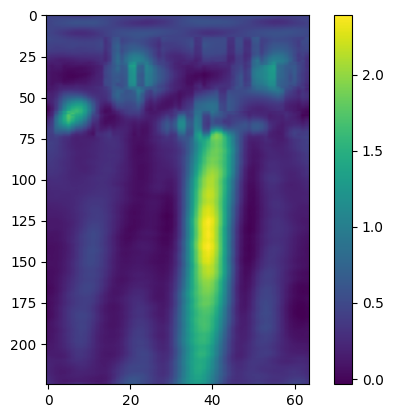

In [42]:
plt.imshow(field_cell_FNO[0,0,10], aspect = 0.4)
plt.colorbar()

(31, 3)


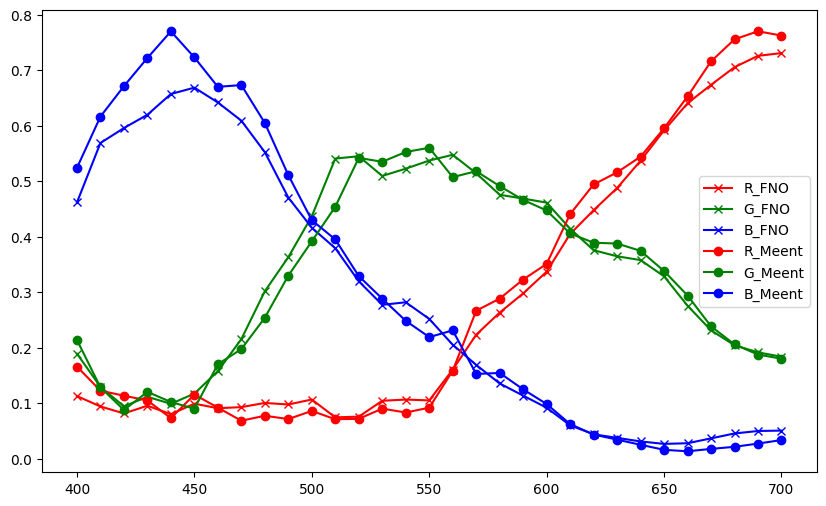

In [43]:
True_response = []

field_cell_meent_Sz_color = meent_sim(best_patterning)

for color in range(len(wav_len_list)):

    wav_len = wav_len_list[color]
    B, G, R, F_Val, F_OX = RGB(wav_len,torch.tensor(field_cell_meent_Sz_color[color,-1,:]))
    True_response.append([R.numpy(), G.numpy(), B.numpy()])
    
True_response = np.array(True_response)

print(np.shape(True_response))

plt.figure(figsize=(10, 6))
plt.plot(wav_len_list, FNO_response[:,0], label="R_FNO", color="r", marker="x")
plt.plot(wav_len_list, FNO_response[:,1], label="G_FNO", color="g", marker="x")
plt.plot(wav_len_list, FNO_response[:,2], label="B_FNO", color="b", marker="x")

plt.plot(wav_len_list, True_response[:,0], label="R_Meent", color="r", marker="o")
plt.plot(wav_len_list, True_response[:,1], label="G_Meent", color="g", marker="o")
plt.plot(wav_len_list, True_response[:,2], label="B_Meent", color="b", marker="o")

plt.legend()
plt.show()

In [44]:
best_Tot_F

tensor(12.0537, dtype=torch.float64)